In [1]:
import numpy as np
import matplotlib.pyplot as plt
import os

In [2]:
experiment_list= [
    'two_body_baseline_hnn_tf',
#     'two_body_baseline_vanilla_tf',
    'two_body_kernel2_stride1',
    'two_body_kernel4_stride2',
    'two_body_kernel8_stride4',
#     'two_body_baseline_resnet_layer1',
#     'two_body_baseline_resnet_layer2',
    'two_body_kernel2_stride1_400',
]

labels = [
    'HNN',
#     'Vanilla',
    'Kernel2Stride1 - 200 epochs',
    'Kernel4Stride2',
    'Kernel8Stride4',
#     'ResnetLayer1',
#     'ResnetLayer2',
    'Kernel2Stride1 - 400 epochs',
]

base_path = '../'


name = 'two_body_baseline_hnn_tf'


variant = 'leapfrog'
variant = 'forward_euler'

In [3]:
# experiment_list= [
#     'two_body_baseline_hnn_tf',
#     'two_body_baseline_vanilla_tf',
#     'two_body_kernel2_stride1_2_good',
#     'two_body_kernel4_stride2',
#     'two_body_kernel8_stride4',
#     'two_body_baseline_resnet_layer1',
#     'two_body_baseline_resnet_layer2',
#     'two_body_kernel2_stride1',
# ]

# labels = [
#     'HNN',
#     'Vanilla',
#     'Kernel2Stride1 - 200 epochs',
#     'Kernel4Stride2',
#     'Kernel8Stride4',
#     'ResnetLayer1',
#     'ResnetLayer2',
#     'Kernel2Stride1 - 400 epochs',
# ]

In [4]:
def get_result_dict(name, variant=None,):
    if 'hnn' in name:
        if variant:
            path_to_result_dict = f'{base_path}/results/ar/{name}/gen_sequence/{variant}/result_dict.npy'
            return np.load(path_to_result_dict, allow_pickle=True).item()
        else:
            raise ValueError('variant must be provided for hnn models (forward_euler or leapfrog)')
    if 'kernel' in name:
        # Need to pick one of the folders within gen_sequence, maybe just pick the first one
        gen_sequence_folders = os.listdir(f'{base_path}/results/ar/{name}/gen_sequence')
        if len(gen_sequence_folders) == 0:
            raise ValueError('No gen_sequence folders found for kernel models')
        gen_sequence_folder = gen_sequence_folders[0]

        path_to_result_dict = f'{base_path}/results/ar/{name}/gen_sequence/{gen_sequence_folder}/result_dict.npy'
        return np.load(path_to_result_dict, allow_pickle=True).item()
    if 'vanilla' in name:
        path_to_result_dict = f'{base_path}/results/ar/{name}/gen_sequence/vanilla/result_dict.npy'
        return np.load(path_to_result_dict, allow_pickle=True).item()
    if 'resnet' in name:
        path_to_result_dict = f'{base_path}/results/ar/{name}/gen_sequence/vanilla/result_dict.npy'
        return np.load(path_to_result_dict, allow_pickle=True).item()

def get_cond_dict(name, variant=None):
    if 'hnn' in name:
        if variant:
            path_to_cond = f'{base_path}/results/ar/{name}/gen_sequence/{variant}/cond_dict.npy'
            return np.load(path_to_cond, allow_pickle=True).item()
        else:
            raise ValueError('variant must be provided for hnn models (forward_euler or leapfrog)')
    if 'kernel' in name:
        # Need to pick one of the folders within gen_sequence, maybe just pick the first one
        gen_sequence_folders = os.listdir(f'{base_path}/results/ar/{name}/gen_sequence')
        if len(gen_sequence_folders) == 0:
            raise ValueError('No gen_sequence folders found for kernel models')
        gen_sequence_folder = gen_sequence_folders[0]
        path_to_cond = f'{base_path}/results/ar/{name}/gen_sequence/{gen_sequence_folder}/cond_dict.npy'
        return np.load(path_to_cond, allow_pickle=True).item()
    if 'vanilla' in name:
        path_to_cond = f'{base_path}/results/ar/{name}/gen_sequence/vanilla/cond_dict.npy'
        return np.load(path_to_cond, allow_pickle=True).item()
    if 'resnet' in name:
        path_to_cond = f'{base_path}/results/ar/{name}/gen_sequence/vanilla/cond_dict.npy'
        return np.load(path_to_cond, allow_pickle=True).item()


In [5]:
for name in experiment_list:
    print(name)
    if 'hnn' in name:
        for variant in ['forward_euler', 'leapfrog']:
            result_dict = get_result_dict(name,variant)
            cond_dict = get_cond_dict(name,variant)

    else:
        result_dict = get_result_dict(name)
        cond_dict = get_cond_dict(name)


two_body_baseline_hnn_tf
two_body_kernel2_stride1
two_body_kernel4_stride2
two_body_kernel8_stride4
two_body_kernel2_stride1_400


In [6]:
def get_q_error(result_dict, cond_dict):
    data = result_dict
    # print(data.keys())
    t=data['t']
    q_gt=data['q_gt']
    q_pred=data['q_pred']

    r_gt=q_gt[:,:,0]
    r_pred=q_pred[:,:,0]
    theta_gt=q_gt[:,:,1]
    theta_pred=q_pred[:,:,1]

    residual_r=np.abs(r_gt-r_pred)
    residual_theta=np.abs(theta_gt-theta_pred)

    return residual_r, residual_theta


In [37]:
plt.rcdefaults()

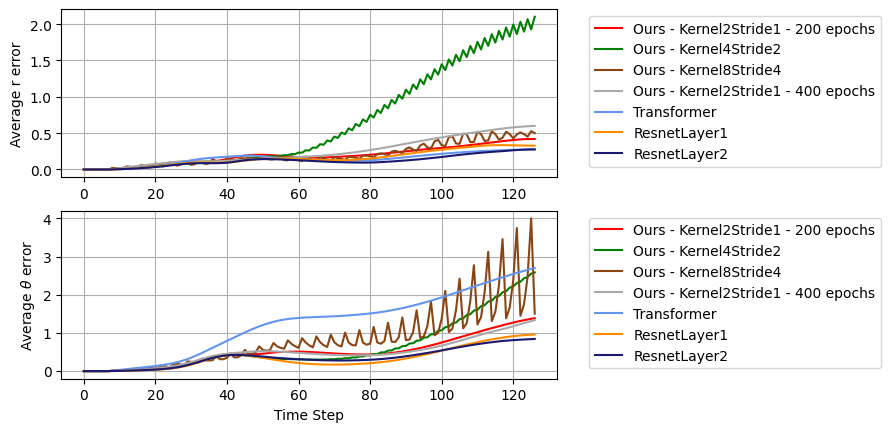

In [ ]:
experiment_list= [
    'two_body_kernel2_stride1',
    'two_body_kernel4_stride2',
    'two_body_kernel8_stride4',
    'two_body_kernel2_stride1_400',
    # 'two_body_baseline_hnn_tf',
    'two_body_baseline_vanilla_tf',

    'two_body_baseline_resnet_layer1',
    'two_body_baseline_resnet_layer2',

]

labels = [
    'Kernel2Stride1 - 200 epochs',
    'Kernel4Stride2',
    'Kernel8Stride4',
    'Kernel2Stride1 - 400 epochs',
    # 'HNN',
    'Transformer',
    'ResnetLayer1',
    'ResnetLayer2',
]

colors = [
    'red',
    'green',
    'saddlebrown',
    'darkgray',
    'cornflowerblue',
    'darkorange',
    'midnightblue'
]
fig, ax = plt.subplots(2,1)
color_idx = 0
for name,label in zip(experiment_list,labels):

    # print(name)
    if 'hnn' in name:


        for variant in ['forward_euler', 'leapfrog']:
            color = colors[color_idx % len(colors)]
            color_idx += 1
            result_dict = get_result_dict(name,variant)
            cond_dict = get_cond_dict(name,variant)
            label_variant = f'{label} - {variant}'
            residual_r, residual_theta = get_q_error(result_dict, cond_dict)
            ax[0].plot(residual_r.mean(axis=0)[:127], label=label_variant, color=color)
            ax[1].plot(residual_theta.mean(axis=0)[:127], label=label_variant, color=color)

    else:
        color = colors[color_idx % len(colors)]
        color_idx += 1
        result_dict = get_result_dict(name)
        cond_dict = get_cond_dict(name)
        residual_r, residual_theta = get_q_error(result_dict, cond_dict)

        if 'kernel' in name:
            ax[0].plot(residual_r.mean(axis=0)[:127], label=f'Ours - {label}', color=color)
            ax[1].plot(residual_theta.mean(axis=0)[:127], label=f'Ours - {label}', color=color)
        else:
            ax[0].plot(residual_r.mean(axis=0)[:127], label=f'{label}', color=color)
            ax[1].plot(residual_theta.mean(axis=0)[:127], label=f'{label}', color=color)


#  move the legent to the right otuside the frame
ax[0].legend(bbox_to_anchor=(1.05, 1))
ax[1].legend(bbox_to_anchor=(1.05, 1))
ax[1].set_xlabel('Time Step')
ax[0].set_ylabel('Average r error')
ax[1].set_ylabel(r'Average $\theta$ error')
ax[0].grid()
ax[1].grid()
plt.show()

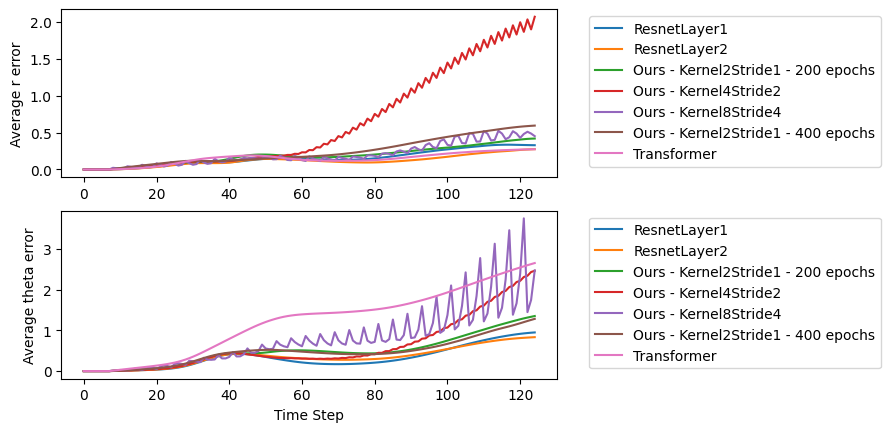

In [8]:
experiment_list= [
    # 'two_body_baseline_hnn_tf',
    'two_body_baseline_resnet_layer1',
    'two_body_baseline_resnet_layer2',
    'two_body_kernel2_stride1',
    'two_body_kernel4_stride2',
    'two_body_kernel8_stride4',
    'two_body_kernel2_stride1_400',
    'two_body_baseline_vanilla_tf',
]

labels = [
    # 'HNN',
    'ResnetLayer1',
    'ResnetLayer2',
    'Kernel2Stride1 - 200 epochs',
    'Kernel4Stride2',
    'Kernel8Stride4',
    'Kernel2Stride1 - 400 epochs',
    'Transformer',
]

fig, ax = plt.subplots(2,1)
for name,label in zip(experiment_list,labels):
    # print(name)
    if 'hnn' in name:
        for variant in ['forward_euler', 'leapfrog']:
            result_dict = get_result_dict(name,variant)
            cond_dict = get_cond_dict(name,variant)
            label_variant = f'{label} - {variant}'
            residual_r, residual_theta = get_q_error(result_dict, cond_dict)
            ax[0].plot(residual_r.mean(axis=0)[:125], label=label_variant)
            ax[1].plot(residual_theta.mean(axis=0)[:125], label=label_variant)

    else:
        result_dict = get_result_dict(name)
        cond_dict = get_cond_dict(name)
        residual_r, residual_theta = get_q_error(result_dict, cond_dict)

        if 'kernel' in name:
            ax[0].plot(residual_r.mean(axis=0)[:125], label=f'Ours - {label}')
            ax[1].plot(residual_theta.mean(axis=0)[:125], label=f'Ours - {label}')
        else:
            ax[0].plot(residual_r.mean(axis=0)[:125], label=f'{label}')
            ax[1].plot(residual_theta.mean(axis=0)[:125], label=f'{label}')


#  move the legent to the right otuside the frame
ax[0].legend(bbox_to_anchor=(1.05, 1))
ax[1].legend(bbox_to_anchor=(1.05, 1))
ax[1].set_xlabel('Time Step')
ax[0].set_ylabel('Average r error')
ax[1].set_ylabel('Average theta error')
plt.show()

# Energy plots

In [9]:
def calculate_energy(results_dict, cond_dict, use_dt = False):

    cond = cond_dict
    data = results_dict

    # Now let's calculate the energy over time
    t = data['t']
    m1 = cond['m1']
    m2 = cond['m2']
    mu = m1*m2/(m1+m2)
    G = 1.0

    q_gt=data['q_gt']
    q_pred=data['q_pred']

    r_gt=q_gt[:,:,0]
    r_pred=q_pred[:,:,0]
    theta_gt=q_gt[:,:,1]
    theta_pred=q_pred[:,:,1]


    if use_dt:
        dt = t[0,1:] - t[0,:-1]    # (T-1,)
    else:
        dt=np.ones(t.shape[1]-1)

    dr_gt = (r_gt[:,1:] - r_gt[:,:-1])/dt[None,:]
    dr_pred = (r_pred[:,1:] - r_pred[:,:-1])/dt[None,:]

    dtheta_gt = (theta_gt[:,1:] - theta_gt[:,:-1])/dt[None,:]
    dtheta_pred = (theta_pred[:,1:] - theta_pred[:,:-1])/dt[None,:]


    # T = mu/2 * (dr**2 + r**2 * dtheta**2)
    # V = -G*M/r

    T_gt = mu.reshape(-1,1)/2 * (dr_gt**2 + (r_gt[:,:-1])**2 * dtheta_gt**2)
    T_pred = mu.reshape(-1,1)/2 * (dr_pred**2 + (r_pred[:,:-1])**2 * dtheta_pred**2)

    V_gt = -(G*m1*m2).reshape(-1,1)/r_gt[:,:-1]
    V_pred = -(G*m1*m2).reshape(-1,1)/r_pred[:,:-1]

    E_gt = T_gt + V_gt
    E_pred = T_pred + V_pred

    return E_gt, E_pred

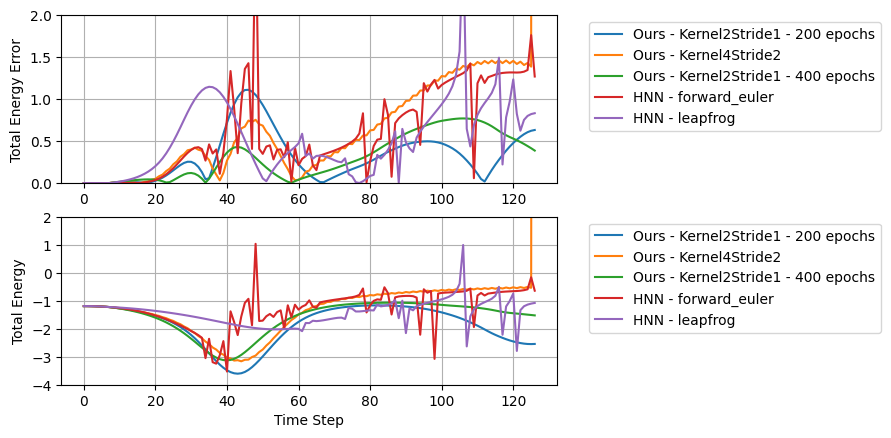

In [45]:
experiment_list= [
    'two_body_kernel2_stride1',
    'two_body_kernel4_stride2',
    # 'two_body_kernel8_stride4',
    'two_body_kernel2_stride1_400',
    'two_body_baseline_hnn_tf',
    # 'two_body_baseline_vanilla_tf',

    # 'two_body_baseline_resnet_layer1',
    # 'two_body_baseline_resnet_layer2',

]

labels = [
    'Kernel2Stride1 - 200 epochs',
    'Kernel4Stride2',
    # 'Kernel8Stride4',
    'Kernel2Stride1 - 400 epochs',
    'HNN',
    # 'Transformer',
    # 'ResnetLayer1',
    # 'ResnetLayer2',
]

colors = [
    'red',
    'green',
    # 'saddlebrown',
    'darkgray',
    'cornflowerblue',
    'darkorange',
    'midnightblue'
]


fig, ax = plt.subplots(2,1)
for name,label in zip(experiment_list,labels):
    # print(name)
    if 'hnn' in name:
        for variant in ['forward_euler', 'leapfrog']:
            result_dict = get_result_dict(name,variant)
            cond_dict = get_cond_dict(name,variant)
            label_variant = f'{label} - {variant}'
            E_gt, E_pred = calculate_energy(result_dict, cond_dict, use_dt=False)
            ax[0].plot(np.abs(E_gt.mean(axis=0)-E_pred.mean(axis=0)), label=label_variant)
            ax[1].plot(E_pred.mean(axis=0), label=label_variant)
    else:
        result_dict = get_result_dict(name)
        cond_dict = get_cond_dict(name)
        E_gt, E_pred = calculate_energy(result_dict, cond_dict, use_dt=False)
        if 'kernel' in name:
            ax[0].plot(np.abs(E_gt.mean(axis=0)-E_pred.mean(axis=0)), label=f'Ours - {label}')
            ax[1].plot(E_pred.mean(axis=0), label=f'Ours - {label}')
        else:
            ax[0].plot(np.abs(E_gt.mean(axis=0)-E_pred.mean(axis=0)), label=f'{label}')
            ax[1].plot(E_pred.mean(axis=0), label=f'{label}')


#  move the legent to the right otuside the frame
ax[0].legend(bbox_to_anchor=(1.05, 1))
ax[1].legend(bbox_to_anchor=(1.05, 1))
ax[1].set_xlabel('Time Step')
ax[0].set_ylabel('Total Energy Error')
ax[1].set_ylabel('Total Energy')
ax[0].set_ylim(0,2)
ax[1].set_ylim(-4,2)
ax[0].grid()
ax[1].grid()
plt.show()

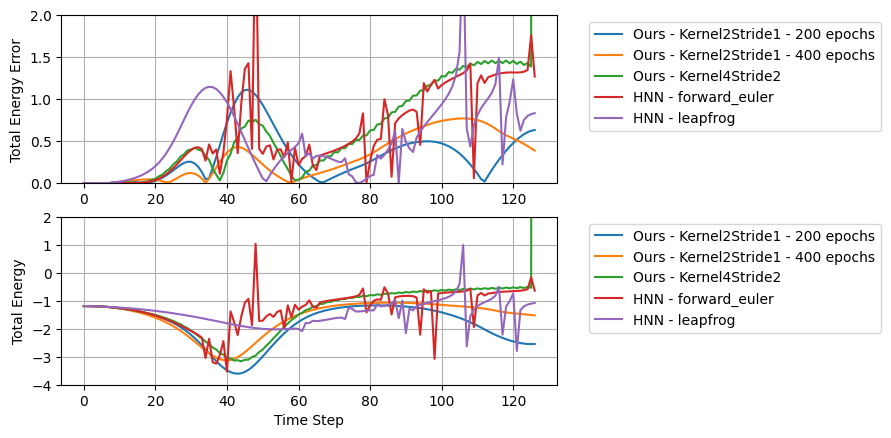

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns



highlight_color = sns.color_palette("bright")[2]   # standout color (orange-ish)
experiment_list= [
    'two_body_kernel2_stride1',
    'two_body_kernel2_stride1_400',
    'two_body_kernel4_stride2',
    'two_body_baseline_hnn_tf',
    # 'two_body_baseline_resnet_layer1',
    # 'two_body_baseline_resnet_layer2',
    # 'two_body_kernel8_stride4',
    # 'two_body_baseline_vanilla_tf',
]

labels = [
    'Kernel2Stride1 - 200 epochs',
    'Kernel2Stride1 - 400 epochs',
    'Kernel4Stride2',
    'HNN',
    # 'ResnetLayer1',
    # 'ResnetLayer2',

    # 'Kernel8Stride4',

    # 'Transformer',
]



fig, ax = plt.subplots(2,1)
for name,label in zip(experiment_list,labels):

    # print(name)
    if 'hnn' in name:
        for variant in ['forward_euler', 'leapfrog']:
            result_dict = get_result_dict(name,variant)
            cond_dict = get_cond_dict(name,variant)
            label_variant = f'{label} - {variant}'
            E_gt, E_pred = calculate_energy(result_dict, cond_dict, use_dt=False)
            ax[0].plot(np.abs(E_gt.mean(axis=0)-E_pred.mean(axis=0)), label=label_variant)
            ax[1].plot(E_pred.mean(axis=0), label=label_variant)
    else:
        result_dict = get_result_dict(name)
        cond_dict = get_cond_dict(name)
        E_gt, E_pred = calculate_energy(result_dict, cond_dict, use_dt=False)
        if 'kernel' in name:
            ax[0].plot(np.abs(E_gt.mean(axis=0)-E_pred.mean(axis=0)), label=f'Ours - {label}')
            ax[1].plot(E_pred.mean(axis=0), label=f'Ours - {label}')
        else:
            ax[0].plot(np.abs(E_gt.mean(axis=0)-E_pred.mean(axis=0)), label=f'{label}')
            ax[1].plot(E_pred.mean(axis=0), label=f'{label}')


#  move the legent to the right otuside the frame
ax[0].legend(bbox_to_anchor=(1.05, 1))
ax[1].legend(bbox_to_anchor=(1.05, 1))
ax[1].set_xlabel('Time Step')
ax[0].set_ylabel('Total Energy Error')
ax[1].set_ylabel('Total Energy')
ax[0].set_ylim(0,2)
ax[1].set_ylim(-4,2)
ax[0].grid()
ax[1].grid()
plt.show()

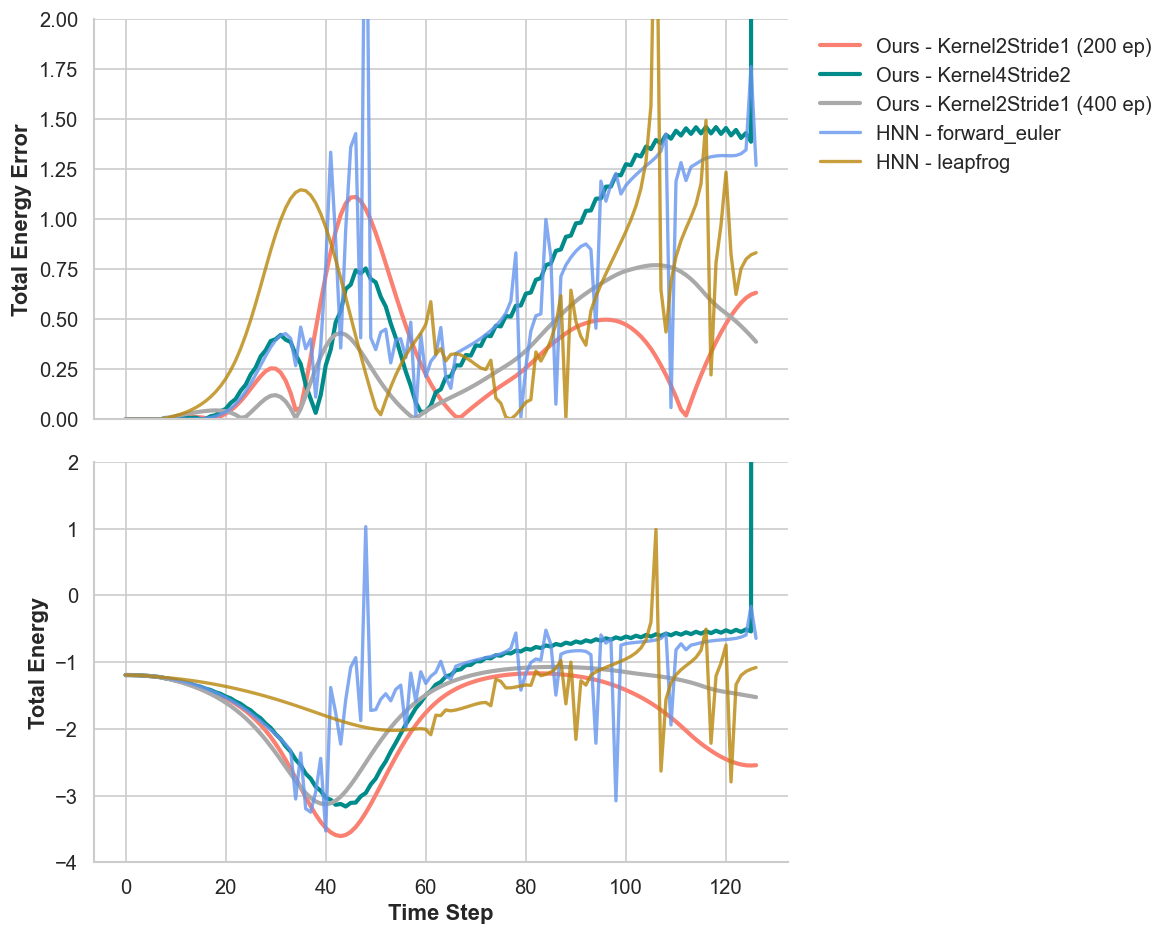

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# --- 1. SETUP STYLING ---
sns.set_theme(style="whitegrid", context="notebook", font_scale=1.1)

experiment_list= [
    'two_body_kernel2_stride1',
    'two_body_kernel4_stride2',
    'two_body_kernel2_stride1_400',
    'two_body_baseline_hnn_tf',
    # 'two_body_baseline_vanilla_tf', # Added to show color cycling
]

labels = [
    'Kernel2Stride1 (200 ep)',
    'Kernel4Stride2',
    'Kernel2Stride1 (400 ep)',
    'HNN',
    # 'Vanilla TF',
]

# --- 3. CUSTOM PALETTE ---
# Your specific requested colors
custom_colors = [
    'salmon',
    'darkcyan',
    'darkgray',
    'cornflowerblue',
    'darkgoldenrod',
    'yellowgreen'
]

# Global counter to assign a unique color to every line drawn
color_idx = 0

fig, ax = plt.subplots(2, 1, figsize=(10, 8), sharex=True, dpi=120)

for name, label in zip(experiment_list, labels):

    if 'hnn' in name:
        for variant in ['forward_euler', 'leapfrog']:
            # Get data
            result_dict = get_result_dict(name, variant)
            cond_dict = get_cond_dict(name, variant)
            E_gt, E_pred = calculate_energy(result_dict, cond_dict)

            label_variant = f'{label} - {variant}'

            # Select color from your custom list
            color = custom_colors[color_idx % len(custom_colors)]
            color_idx += 1

            # Plotting (Dashed for HNN/Baselines)
            ax[0].plot(np.abs(E_gt.mean(axis=0) - E_pred.mean(axis=0)),
                       label=label_variant, color=color, linewidth=2, alpha=0.8)
            ax[1].plot(E_pred.mean(axis=0),
                       label=label_variant, color=color, linewidth=2, alpha=0.8)

    else:
        # Get data
        result_dict = get_result_dict(name)
        cond_dict = get_cond_dict(name)
        E_gt, E_pred = calculate_energy(result_dict, cond_dict)

        # Select color from your custom list
        color = custom_colors[color_idx % len(custom_colors)]
        color_idx += 1

        final_label = f'Ours - {label}' if 'kernel' in name else label

        # Plotting (Solid for your methods)
        ax[0].plot(np.abs(E_gt.mean(axis=0) - E_pred.mean(axis=0)),
                   label=final_label, color=color, linestyle='-', linewidth=2.5)
        ax[1].plot(E_pred.mean(axis=0),
                   label=final_label, color=color, linestyle='-', linewidth=2.5)


# --- 4. FORMATTING ---
# Legend outside top right
ax[0].legend(bbox_to_anchor=(1.02, 1), loc='upper left', frameon=False)

# Labels
ax[1].set_xlabel('Time Step', fontweight='bold')
ax[0].set_ylabel('Total Energy Error', fontweight='bold')
ax[1].set_ylabel('Total Energy', fontweight='bold')

# Y-Limits (from your original code)
ax[0].set_ylim(0, 2)
ax[1].set_ylim(-4, 2)

# Aesthetic cleanup
sns.despine() # Removes top and right borders
plt.tight_layout()
plt.show()

---


In [13]:
# def get_result_dict_test(name, variant=None,):
#     if 'hnn' in name:
#         if variant:
#             path_to_result_dict = f'{base_path}/results/ar/{name}/gen_sequence_test/{variant}/result_dict.npy'
#             return np.load(path_to_result_dict, allow_pickle=True).item()
#         else:
#             raise ValueError('variant must be provided for hnn models (forward_euler or leapfrog)')
#     if 'kernel' in name:
#         # Need to pick one of the folders within gen_sequence_test, maybe just pick the first one
#         gen_sequence_folders = os.listdir(f'{base_path}/results/ar/{name}/gen_sequence_test')
#         if len(gen_sequence_folders) == 0:
#             raise ValueError('No gen_sequence_test folders found for kernel models')
#         gen_sequence_folder = gen_sequence_folders[0]

#         path_to_result_dict = f'{base_path}/results/ar/{name}/gen_sequence_test/{gen_sequence_folder}/result_dict.npy'
#         return np.load(path_to_result_dict, allow_pickle=True).item()
#     if 'vanilla' in name:
#         path_to_result_dict = f'{base_path}/results/ar/{name}/gen_sequence_test/vanilla/result_dict.npy'
#         return np.load(path_to_result_dict, allow_pickle=True).item()
#     if 'resnet' in name:
#         path_to_result_dict = f'{base_path}/results/ar/{name}/gen_sequence_test/vanilla/result_dict.npy'
#         return np.load(path_to_result_dict, allow_pickle=True).item()

# def get_cond_dict_test(name, variant=None):
#     if 'hnn' in name:
#         if variant:
#             path_to_cond = f'{base_path}/results/ar/{name}/gen_sequence_test/{variant}/cond_dict.npy'
#             return np.load(path_to_cond, allow_pickle=True).item()
#         else:
#             raise ValueError('variant must be provided for hnn models (forward_euler or leapfrog)')
#     if 'kernel' in name:
#         # Need to pick one of the folders within gen_sequence_test, maybe just pick the first one
#         gen_sequence_folders = os.listdir(f'{base_path}/results/ar/{name}/gen_sequence_test')
#         if len(gen_sequence_folders) == 0:
#             raise ValueError('No gen_sequence_test folders found for kernel models')
#         gen_sequence_folder = gen_sequence_folders[0]
#         path_to_cond = f'{base_path}/results/ar/{name}/gen_sequence_test/{gen_sequence_folder}/cond_dict.npy'
#         return np.load(path_to_cond, allow_pickle=True).item()
#     if 'vanilla' in name:
#         path_to_cond = f'{base_path}/results/ar/{name}/gen_sequence_test/vanilla/cond_dict.npy'
#         return np.load(path_to_cond, allow_pickle=True).item()
#     if 'resnet' in name:
#         path_to_cond = f'{base_path}/results/ar/{name}/gen_sequence_test/vanilla/cond_dict.npy'
#         return np.load(path_to_cond, allow_pickle=True).item()


In [14]:
# experiment_list= [
#     'two_body_baseline_hnn_tf',
# #     'two_body_baseline_vanilla_tf',
#     'two_body_kernel2_stride1',
#     'two_body_kernel4_stride2',
#     'two_body_kernel8_stride4',
# #     'two_body_baseline_resnet_layer1',
# #     'two_body_baseline_resnet_layer2',
# ]

# labels = [
#     'HNN',
# #     'Vanilla',
#     'Kernel2Stride1 - 200 epochs',
#     'Kernel4Stride2',
#     'Kernel8Stride4',
# #     'ResnetLayer1',
# #     'ResnetLayer2',
# ]

# fig, ax = plt.subplots(2,1)
# for name,label in zip(experiment_list,labels):
#     # print(name)
#     if 'hnn' in name:
#         for variant in ['forward_euler', 'leapfrog']:
#             result_dict = get_result_dict_test(name,variant)
#             cond_dict = get_cond_dict_test(name,variant)
#             label_variant = f'{label} - {variant}'
#             residual_r, residual_theta = get_q_error(result_dict, cond_dict)
#             ax[0].plot(residual_r.mean(axis=0)[:125], label=label_variant)
#             ax[1].plot(residual_theta.mean(axis=0)[:125], label=label_variant)

#     else:
#         result_dict = get_result_dict_test(name)
#         cond_dict = get_cond_dict_test(name)
#         residual_r, residual_theta = get_q_error(result_dict, cond_dict)

#         if 'kernel' in name:
#             ax[0].plot(residual_r.mean(axis=0)[:125], label=f'Ours - {label}')
#             ax[1].plot(residual_theta.mean(axis=0)[:125], label=f'Ours - {label}')
#         else:
#             ax[0].plot(residual_r.mean(axis=0)[:125], label=f'{label}')
#             ax[1].plot(residual_theta.mean(axis=0)[:125], label=f'{label}')


# #  move the legent to the right otuside the frame
# ax[0].legend(bbox_to_anchor=(1.05, 1))
# ax[1].legend(bbox_to_anchor=(1.05, 1))
# ax[1].set_xlabel('Time Step')
# ax[0].set_ylabel('Average r error')
# ax[1].set_ylabel('Average theta error')
# ax[0].set_title('Test Set - Position Errors')
# ax[1].set_title('Test Set - Angle Errors')
# plt.show()


In [15]:
# experiment_list= [
#     # 'two_body_baseline_hnn_tf',
#     'two_body_baseline_resnet_layer1',
#     'two_body_baseline_resnet_layer2',
#     'two_body_kernel2_stride1',
#     'two_body_kernel4_stride2',
#     # 'two_body_kernel8_stride4',
#     'two_body_baseline_vanilla_tf',
# ]

# labels = [
#     # 'HNN',
#     'ResnetLayer1',
#     'ResnetLayer2',
#     'Kernel2Stride1 - 200 epochs',
#     'Kernel4Stride2',
#     # 'Kernel8Stride4',
#     'Transformer',
# ]

# fig, ax = plt.subplots(2,1)
# for name,label in zip(experiment_list,labels):
#     # print(name)
#     if 'hnn' in name:
#         for variant in ['forward_euler', 'leapfrog']:
#             result_dict = get_result_dict_test(name,variant)
#             cond_dict = get_cond_dict_test(name,variant)
#             label_variant = f'{label} - {variant}'
#             residual_r, residual_theta = get_q_error(result_dict, cond_dict)
#             ax[0].plot(residual_r.mean(axis=0)[:125], label=label_variant)
#             ax[1].plot(residual_theta.mean(axis=0)[:125], label=label_variant)

#     else:
#         result_dict = get_result_dict_test(name)
#         cond_dict = get_cond_dict_test(name)
#         residual_r, residual_theta = get_q_error(result_dict, cond_dict)

#         if 'kernel' in name:
#             ax[0].plot(residual_r.mean(axis=0)[:125], label=f'Ours - {label}')
#             ax[1].plot(residual_theta.mean(axis=0)[:125], label=f'Ours - {label}')
#         else:
#             ax[0].plot(residual_r.mean(axis=0)[:125], label=f'{label}')
#             ax[1].plot(residual_theta.mean(axis=0)[:125], label=f'{label}')


# #  move the legent to the right otuside the frame
# ax[0].legend(bbox_to_anchor=(1.05, 1))
# ax[1].legend(bbox_to_anchor=(1.05, 1))
# ax[1].set_xlabel('Time Step')
# ax[0].set_ylabel('Average r error')
# ax[1].set_ylabel('Average theta error')
# ax[0].set_title('Test Set - Position Errors')
# ax[1].set_title('Test Set - Angle Errors')
# plt.show()


In [16]:
# experiment_list= [
#     # 'two_body_baseline_hnn_tf',
#     'two_body_baseline_resnet_layer1',
#     'two_body_baseline_resnet_layer2',
#     'two_body_kernel2_stride1',
#     'two_body_kernel4_stride2',
#     # 'two_body_kernel8_stride4',
#     'two_body_baseline_vanilla_tf',
# ]

# labels = [
#     # 'HNN',
#     'ResnetLayer1',
#     'ResnetLayer2',
#     'Kernel2Stride1 - 200 epochs',
#     'Kernel4Stride2',
#     # 'Kernel8Stride4',
#     'Transformer',
# ]

# fig, ax = plt.subplots(2,1)
# for name,label in zip(experiment_list,labels):
#     # print(name)
#     if 'hnn' in name:
#         for variant in ['forward_euler', 'leapfrog']:
#             result_dict = get_result_dict_test(name,variant)
#             cond_dict = get_cond_dict_test(name,variant)
#             label_variant = f'{label} - {variant}'
#             E_gt, E_pred = calculate_energy(result_dict, cond_dict, use_dt=False)
#             ax[0].plot(np.abs(E_gt.mean(axis=0)-E_pred.mean(axis=0)), label=label_variant)
#             ax[1].plot(E_pred.mean(axis=0), label=label_variant)
#     else:
#         result_dict = get_result_dict_test(name)
#         cond_dict = get_cond_dict_test(name)
#         E_gt, E_pred = calculate_energy(result_dict, cond_dict, use_dt=False)
#         if 'kernel' in name:
#             ax[0].plot(np.abs(E_gt.mean(axis=0)-E_pred.mean(axis=0)), label=f'Ours - {label}')
#             ax[1].plot(E_pred.mean(axis=0), label=f'Ours - {label}')
#         else:
#             ax[0].plot(np.abs(E_gt.mean(axis=0)-E_pred.mean(axis=0)), label=f'{label}')
#             ax[1].plot(E_pred.mean(axis=0), label=f'{label}')


# #  move the legent to the right otuside the frame
# ax[0].legend(bbox_to_anchor=(1.05, 1))
# ax[1].legend(bbox_to_anchor=(1.05, 1))
# ax[1].set_xlabel('Time Step')
# ax[0].set_ylabel('Total Energy Error')
# ax[1].set_ylabel('Total Energy')
# ax[0].set_title('Test Set - Energy Error')
# ax[1].set_title('Test Set - Total Energy')
# ax[0].set_ylim(0,2)
# ax[1].set_ylim(-4,2)
# plt.show()


--- 

## Now for the test ones